In [1]:
!pip install -q transformers datasets torchaudio librosa soundfile
!pip install -q scikit-learn matplotlib

In [2]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import librosa
import soundfile as sf

from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
SAMPLE_RATE = 16000
MAX_DURATION = 5
MAX_LENGTH = SAMPLE_RATE * MAX_DURATION

BATCH_SIZE = 64
LEARNING_RATE = 1e-5
NUM_EPOCHS = 5

LABEL_MAP = {
    "real": 0,
    "fake": 1
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [26]:
MODEL_NAME = "facebook/wav2vec2-base"

processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.freeze_feature_encoder()

model.to(DEVICE)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
projector.weight             | MISSING    | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)


In [7]:
from pathlib import Path

DATASET_DIR = Path("/content/drive/MyDrive/audio_data")  # change if needed
REAL_FOLDER_NAME = "real_samples"

audio_extensions = {".wav", ".mp3", ".flac", ".ogg", ".m4a"}

rows = []

for subfolder in DATASET_DIR.iterdir():
    if not subfolder.is_dir():
        continue

    folder_name = subfolder.name
    label = 0 if folder_name == REAL_FOLDER_NAME else 1

    for file_path in subfolder.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in audio_extensions:
            rows.append({
                "path": str(file_path),
                "label": label,
                "source": folder_name
            })

df = pd.DataFrame(rows)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.head())

print("\nLabel counts:")
print(df["label"].value_counts())

print("\nSource counts:")
print(df["source"].value_counts())

print("\nTotal files:", len(df))

                                                path  label        source
0  /content/drive/MyDrive/audio_data/OpenAI/echo_...      1        OpenAI
1  /content/drive/MyDrive/audio_data/VALLE/3570-5...      1         VALLE
2  /content/drive/MyDrive/audio_data/real_samples...      0  real_samples
3  /content/drive/MyDrive/audio_data/OpenAI/fable...      1        OpenAI
4  /content/drive/MyDrive/audio_data/real_samples...      0  real_samples

Label counts:
label
0    2270
1    2171
Name: count, dtype: int64

Source counts:
source
real_samples      2270
OpenAI             600
xTTS               600
seedtts_files      599
FlashSpeech        118
VoiceBox           104
VALLE               93
NaturalSpeech3      32
PromptTTS2          25
Name: count, dtype: int64

Total files: 4441


In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nTrain label counts:")
print(train_df["label"].value_counts())

print("\nVal label counts:")
print(val_df["label"].value_counts())

print("\nTest label counts:")
print(test_df["label"].value_counts())

Train: 3108
Val: 666
Test: 667

Train label counts:
label
0    1589
1    1519
Name: count, dtype: int64

Val label counts:
label
0    340
1    326
Name: count, dtype: int64

Test label counts:
label
0    341
1    326
Name: count, dtype: int64


In [9]:
print("Unique sources:")
print(sorted(df["source"].unique()))

print("\nReal examples:")
print(df[df["label"] == 0]["source"].value_counts())

print("\nFake examples:")
print(df[df["label"] == 1]["source"].value_counts())

Unique sources:
['FlashSpeech', 'NaturalSpeech3', 'OpenAI', 'PromptTTS2', 'VALLE', 'VoiceBox', 'real_samples', 'seedtts_files', 'xTTS']

Real examples:
source
real_samples    2270
Name: count, dtype: int64

Fake examples:
source
OpenAI            600
xTTS              600
seedtts_files     599
FlashSpeech       118
VoiceBox          104
VALLE              93
NaturalSpeech3     32
PromptTTS2         25
Name: count, dtype: int64


In [10]:
def load_audio(path, sample_rate=SAMPLE_RATE, max_length=MAX_LENGTH):
    audio, sr = librosa.load(path, sr=sample_rate)

    if len(audio) > max_length:
        audio = audio[:max_length]
    else:
        pad_width = max_length - len(audio)
        audio = np.pad(audio, (0, pad_width), mode="constant")

    return audio

In [11]:
class DeepfakeAudioDataset(Dataset):
    def __init__(self, dataframe, processor):
        self.dataframe = dataframe
        self.processor = processor

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        audio = load_audio(row["path"])
        label = int(row["label"])

        inputs = self.processor(
            audio,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
            padding=False
        )

        item = {
            "input_values": inputs["input_values"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

        if "attention_mask" in inputs:
            item["attention_mask"] = inputs["attention_mask"].squeeze(0)

        return item

In [12]:
train_dataset = DeepfakeAudioDataset(train_df, processor)
val_dataset = DeepfakeAudioDataset(val_df, processor)
test_dataset = DeepfakeAudioDataset(test_df, processor)

print("Datasets loaded")

Datasets loaded


In [21]:
class AudioDataCollator:
    def __init__(self, processor, padding=True):
        self.processor = processor
        self.padding = padding

    def __call__(self, features):
        input_features = [{"input_values": f["input_values"]} for f in features]
        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt"
        )

        batch["labels"] = torch.tensor([f["labels"] for f in features], dtype=torch.long)
        return batch

data_collator = AudioDataCollator(processor=processor)

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [27]:
training_args = TrainingArguments(
    output_dir="./wav2vec2-deepfake-checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    dataloader_num_workers=4
)

In [28]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [29]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.639300,0.473435,0.867868,0.934307,0.785276,0.853333
2,0.292802,0.147770,0.980480,1.000000,0.960123,0.979656
3,0.118051,0.100187,0.978979,0.996815,0.960123,0.978125
4,0.073261,0.070577,0.986486,0.996865,0.975460,0.986047
5,0.053783,0.064690,0.989489,0.996885,0.981595,0.989181


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=245, training_loss=0.23543938520003338, metrics={'train_runtime': 658.3213, 'train_samples_per_second': 23.605, 'train_steps_per_second': 0.372, 'total_flos': 7.05409756128e+17, 'train_loss': 0.23543938520003338, 'epoch': 5.0})

In [30]:
test_results = trainer.evaluate(test_dataset)
print(test_results)

{'eval_loss': 0.07948843389749527, 'eval_accuracy': 0.9820089955022488, 'eval_precision': 0.9875776397515528, 'eval_recall': 0.9754601226993865, 'eval_f1': 0.9814814814814815, 'eval_runtime': 155.2982, 'eval_samples_per_second': 4.295, 'eval_steps_per_second': 0.071, 'epoch': 5.0}


In [31]:
pred_output = trainer.predict(test_dataset)
preds = np.argmax(pred_output.predictions, axis=1)
labels = pred_output.label_ids

cm = confusion_matrix(labels, preds)
print("Confusion Matrix:\n", cm)

from sklearn.metrics import classification_report
print("\nClassification Report:\n")
print(classification_report(labels, preds, target_names=["real", "fake"]))

Confusion Matrix:
 [[337   4]
 [  8 318]]

Classification Report:

              precision    recall  f1-score   support

        real       0.98      0.99      0.98       341
        fake       0.99      0.98      0.98       326

    accuracy                           0.98       667
   macro avg       0.98      0.98      0.98       667
weighted avg       0.98      0.98      0.98       667



In [32]:
SAVE_DIR = "./final_wav2vec2_deepfake_model"

trainer.save_model(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)

print(f"Saved model to {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to ./final_wav2vec2_deepfake_model


In [33]:
import pandas as pd

log_df = pd.DataFrame(trainer.state.log_history)
log_df.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.639300,1.325040,0.000008,1.0,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,49,0.473435,0.867868,0.934307,0.785276,0.853333,157.2691,4.235,0.070,NaN,NaN,NaN,NaN,NaN
2,0.292802,1.177683,0.000006,2.0,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,98,0.147770,0.980480,1.000000,0.960123,0.979656,1.3518,492.668,8.137,NaN,NaN,NaN,NaN,NaN
4,0.118051,1.905526,0.000004,3.0,147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


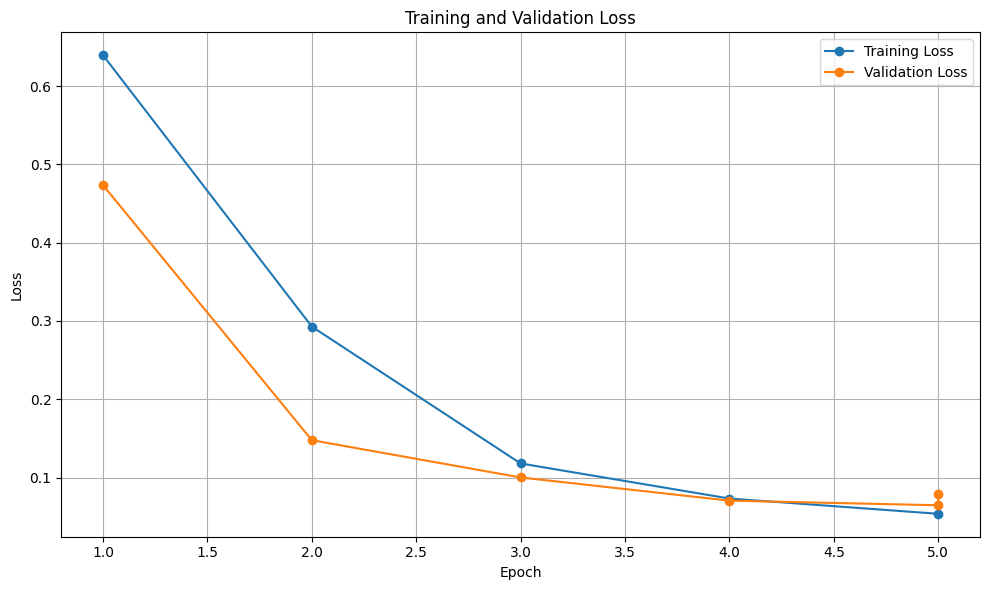

In [34]:
import matplotlib.pyplot as plt

# Separate training and eval rows
train_logs = log_df[log_df["loss"].notna()].copy()
eval_logs = log_df[log_df["eval_loss"].notna()].copy()

plt.figure(figsize=(10, 6))

# Loss curves
if not train_logs.empty:
    plt.plot(train_logs["epoch"], train_logs["loss"], marker="o", label="Training Loss")
if not eval_logs.empty:
    plt.plot(eval_logs["epoch"], eval_logs["eval_loss"], marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()

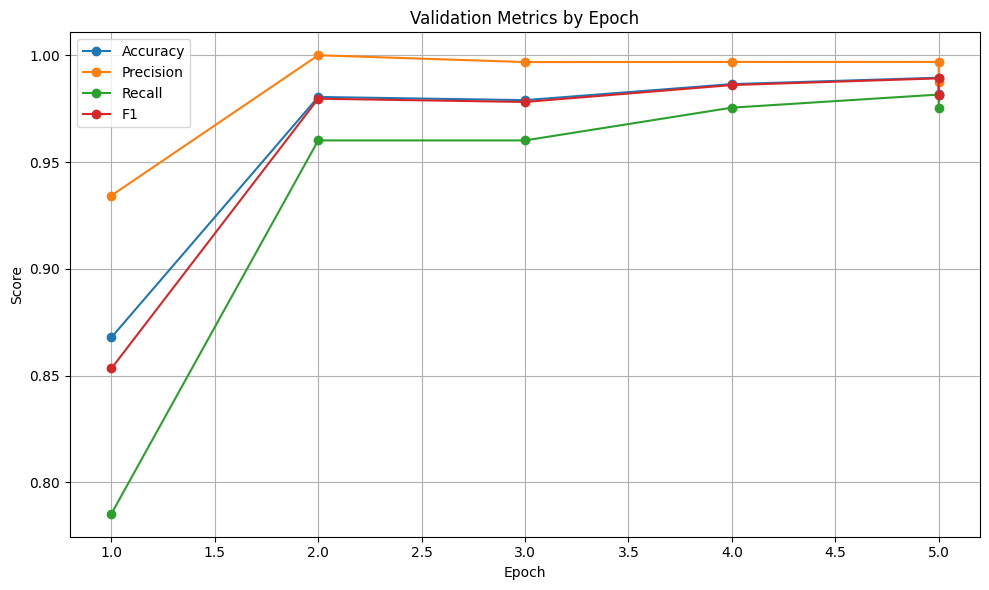

In [35]:
plt.figure(figsize=(10, 6))

for metric in ["eval_accuracy", "eval_precision", "eval_recall", "eval_f1"]:
    if metric in eval_logs.columns:
        plt.plot(eval_logs["epoch"], eval_logs[metric], marker="o", label=metric.replace("eval_", "").capitalize())

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics by Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("validation_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

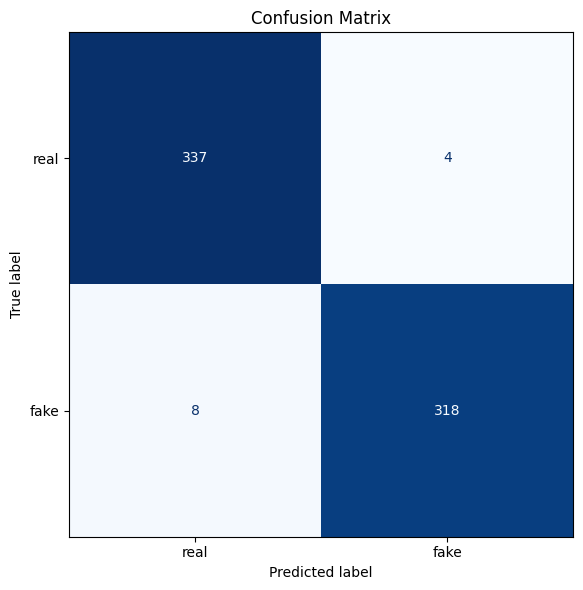

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

pred_output = trainer.predict(test_dataset)
preds = np.argmax(pred_output.predictions, axis=1)
labels = pred_output.label_ids

cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["real", "fake"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

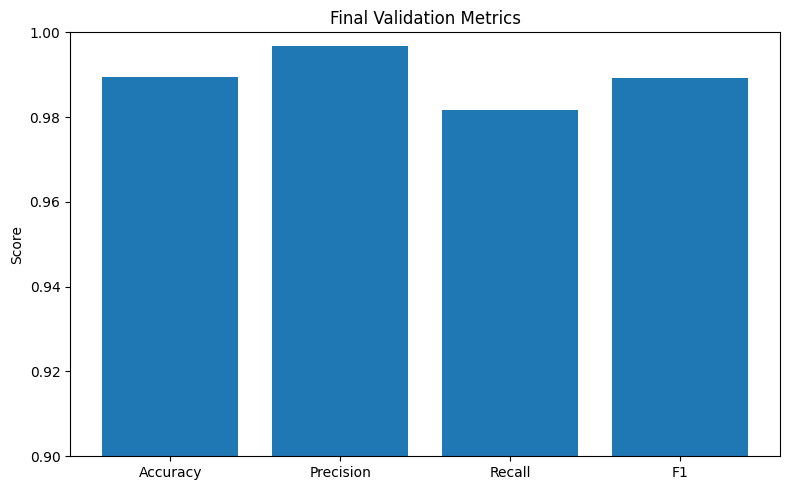

In [37]:
final_metrics = {
    "Accuracy": 0.989489,
    "Precision": 0.996885,
    "Recall": 0.981595,
    "F1": 0.989181
}

names = list(final_metrics.keys())
values = list(final_metrics.values())

plt.figure(figsize=(8, 5))
plt.bar(names, values)
plt.ylim(0.9, 1.0)
plt.ylabel("Score")
plt.title("Final Validation Metrics")
plt.tight_layout()

plt.savefig("final_metrics_bar.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
test_df = test_df.copy()

test_df["pred"] = preds
test_df["correct"] = (test_df["pred"] == test_df["label"]).astype(int)

In [39]:
source_accuracy = test_df.groupby("source")["correct"].mean().sort_values(ascending=False)

print(source_accuracy)

source
OpenAI            1.000000
xTTS              1.000000
PromptTTS2        1.000000
VoiceBox          1.000000
real_samples      0.988270
seedtts_files     0.986842
FlashSpeech       0.958333
VALLE             0.833333
NaturalSpeech3    0.250000
Name: correct, dtype: float64


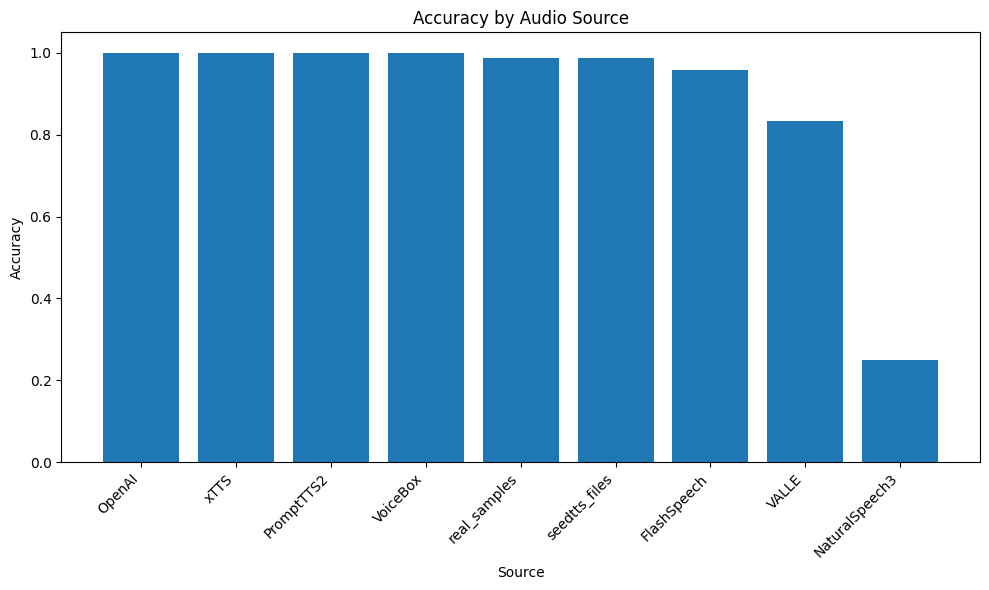

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(source_accuracy.keys(), source_accuracy.values)

plt.ylabel("Accuracy")
plt.xlabel("Source")
plt.title("Accuracy by Audio Source")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("accuracy_by_source.png", dpi=300, bbox_inches="tight")
plt.show()

In [56]:
import nbformat

input_path = "/content/drive/MyDrive/Colab_Notebooks/DeepFake_Audio_Detector.ipynb"   # change this
output_path = "/content/fixed_notebook.ipynb"

nb = nbformat.read(input_path, as_version=4)

# Remove widget metadata
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, output_path)

print("Fixed notebook saved at:", output_path)

Fixed notebook saved at: /content/fixed_notebook.ipynb
